# Vector Reorientation Dynamics (VRD)

This notebook demonstrates how to compute the **reorientation autocorrelation function** *C*ˡ(t) of a molecular vector (e.g. an O–H bond or a C–C bond) and extract its characteristic reorientation time τ.

**Theory — Legendre polynomial autocorrelation:**

$$C^l(t) = \langle P_l[\hat{\mathbf{u}}(0) \cdot \hat{\mathbf{u}}(t)] \rangle$$

where $\hat{\mathbf{u}}(t)$ is the unit vector at time *t* and $P_l$ is the *l*-th Legendre polynomial:

| *l* | $P_l(x)$ | Experiment |
|-----|-----------|------------|
| 1 | $x$ | — |
| 2 | $\tfrac{1}{2}(3x^2-1)$ | NMR T₁, dielectric relaxation |
| 3 | $\tfrac{1}{2}(5x^3-3x)$ | Raman / IR |

*C*ˡ decays from 1 to 0. At long times it is fitted with the **Kohlrausch–Williams–Watts (KWW)** stretched exponential:

$$C^l(t) = \exp\!\left[-\left(\frac{t}{\tau}\right)^\beta\right], \quad 0 < \beta \leq 1$$

Topics covered:
1. O–H bond reorientation dynamics of water molecules (l = 1)
2. C–C bond reorientation of trifluoroacetate (TFA) anions (l = 3)
3. Comparing individual-bond vs. ensemble-averaged *C*ˡ(t)
4. KWW fitting to extract τ and β

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fishmol import trj, funcs, style
from cage_data import cage1_info

## Read trajectory file

In [2]:
%%time
cell = cage1_info.cell
# cell is a fallback: this NVT file has no Lattice= in frame comments
traj = trj.Trajectory(timestep = 5, data = "/nobackup/rhtp48/data_ana/cage1-500K.xyz", index = ":", cell = cell)

CPU times: user 2min 17s, sys: 7.39 s, total: 2min 24s
Wall time: 2min 27s


## O–H Bond Reorientation of Water Molecules

`funcs.VRD` parameters:
- **`traj`** — `Trajectory` object
- **`spec`** — atom specification: `[donor_idx, [H1_idx, H2_idx, …]]` for multiple vectors from one atom, or `[[g1_indices], [g2_indices]]` for paired groups
- **`num`** — number of frames per chunk (window length for time-origin averaging)
- **`sampling`** — stride within each chunk (every *n*-th frame is used)
- **`skip`** — stride across chunks (every *n*-th chunk is used for averaging)
- **`l`** — Legendre polynomial order (1, 2, or 3)
- **`mean`** — if `True`, average *C*ˡ over all vector pairs; if `False`, return one curve per pair
- **`fit`** — if `True`, fit the decay with KWW and plot the result

### Sepearately calculate the O-H bonds

Progress: [■■■■■■■■■■■■■■■■■■■■] 100.0%


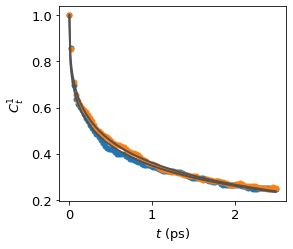

In [186]:
water_vrd = funcs.VRD(traj = traj, spec = [14, [15, 16]], num = 500, sampling = 5, skip = 2)
results = water_vrd.calculate(l = 1, mean = False, fit = True, plot = True)

### Average the O-H bonds of the same water molecule

Progress: [■■■■■■■■■■■■■■■■■■■■] 100.0%


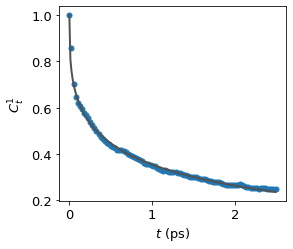

In [187]:
water_vrd = funcs.VRD(traj = traj, spec = [14, [15, 16]], num = 500, sampling = 5, skip = 2)
results = water_vrd.calculate(l = 1, mean = True, fit = True, plot = True)

### Plot the results by yourself

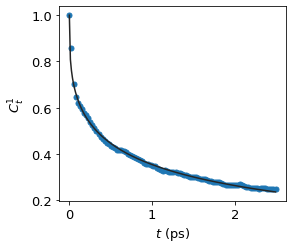

In [190]:
fig, ax = plt.subplots()

ax.scatter(results.t, results.C_t)
ax.plot(results.t_fit, results.C_t_fit, color = "#252525")

ax.set_xlabel(r"$t$ (ps)")
ax.set_ylabel(r"$C^1_t$")
plt.show()

## TFA O···O Vector Reorientation (*l* = 3)

For TFA anions we track the vector connecting the two carboxylate oxygens (O1···O2), which is a proxy for the tumbling of the CF₃COO⁻ ion. Because this vector is along the C–C bond axis, its reorientation reflects the overall rotational motion of the anion.

We use *l* = 3, which probes the same dynamics as Raman spectroscopy and is more sensitive to fast librational motion than *l* = 2.

### Single TFA — individual O···O vector

### Calculate the C-C bond reorientation dynamics in one TFA anion

In [3]:
TFAs = cage1_info.TFAs
spec = [*TFAs[0].values()]

In [4]:
spec

[0, 1, 2, 3, 4, 5, 6]

In [5]:
print([x for x in spec if traj.frames[0][x].symbs == "O"])

[3, 4]


In [ ]:
vrd = funcs.VRD(traj=traj, spec=[3, 4], num=2000, sampling=10, skip=5)
results = vrd.calculate(l=3, mean=False, fit=True, plot=True)

In [6]:
all_oxygen = [x for spec in TFAs for x in [*spec.values()] if traj.frames[0][x].symbs == "O"]

In [7]:
specs = [[x for x in all_oxygen[::2]], [x for x in all_oxygen[1::2]]]
specs

[[3, 10, 132, 139, 261, 268, 390, 397], [4, 11, 133, 140, 262, 269, 391, 398]]

### All TFA ions — ensemble average

By passing two lists of atom indices (one per end of the vector) `funcs.VRD` computes *C*ˡ for every O1ᵢ···O2ᵢ pair in parallel and averages them. This reduces statistical noise and gives the ensemble-average reorientation time of the TFA anion.

Progress: [■■■■■■■■■■■■■■■■■■■■] 100.0%


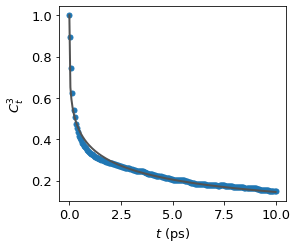

In [10]:
vrd = funcs.VRD(traj = traj, spec = specs, num = 2000, sampling = 10, skip = 5)
results = vrd.calculate(l = 3, mean = True, fit = True, plot = True)